In [1]:
!hostnamectl

 Static hostname: gpue02.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: 03b8ad4d5da846abbb331a11f6309515
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: CUXD670_5.32_v2.06


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [2]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [4]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [5]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [6]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_young_female.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [7]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 3902 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'age_sex', 'intervals_young'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

# MuSC to type1/2 transitions

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['MuSC', 'Type II', 'Type I', 'Specialized MF'])].copy()

In [ ]:
rna_adata.obs['age_sex'] = (
    rna_adata.obs['age'].astype('float').astype(int).astype(str)
    + '_' + 
    rna_adata.obs['Sex'].astype(str)
)
rna_adata.obs['age_sex'].value_counts().sort_index()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '15_Male': 'interval_1_M',
    '18_Male': 'interval_1_M',
    '34_Male': 'interval_2_M',
    '38_Male': 'interval_2_M',
    '45_Male': 'interval_2_M',
    # Female intervals
    '17_Female': 'interval_1_F',
    '29_Female': 'interval_1_F',
    '34_Female': 'interval_2_F',
}

rna_adata.obs['intervals_young'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

# Verify
rna_adata.obs['intervals_young'].value_counts()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '77_Male': 'interval_1_M',
    '79_Male': 'interval_1_M',
    '82_Male': 'interval_1_M',
    '84_Male': 'interval_1_M',
    '85_Male': 'interval_2_M',
    '88_Male': 'interval_2_M',
    # Female intervals
    '79_Female': 'interval_1_F',
    '80_Female': 'interval_1_F',
    '82_Female': 'interval_1_F',
    '84_Female': 'interval_2_F',
    '89_Female': 'interval_2_F',
    '92_Female': 'interval_2_F',
    '99_Female': 'interval_2_F'
}

rna_adata.obs['intervals_old'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

rna_adata.obs['intervals_old'].value_counts()

In [ ]:
mask = (
    # interval_1: MuSC only
    (rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_1_F']) & 
     (rna_adata.obs['Annotation'] == 'MuSC'))
    |
    # interval_2: Type II, Type I, Specialized MF only (no MuSC)
    (rna_adata.obs['intervals_old'].isin(['interval_2_M', 'interval_2_F']) & 
     rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'Specialized MF']))
)

rna_adata = rna_adata[mask].copy()

# Verify — should show no MuSC in interval_2 and no other types in interval_1
rna_adata.obs.groupby(['intervals_old', 'Annotation']).size()

In [ ]:
n_cells_downsample = 2000
adatas = []

for interval, idx in rna_adata.obs.groupby('intervals_old').groups.items():
    subset = rna_adata[idx].copy()
    
    if interval.startswith('interval_2') and subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

print(rna_adata.obs['intervals_old'].value_counts())

In [ ]:
# subset adata to male and female cells based on intervals_young
rna_adata_male = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_2_M'])].copy()
rna_adata_female = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_F', 'interval_2_F'])].copy()

In [ ]:
rna_adata_female.obs

In [ ]:

import anndata as ad
ad.settings.allow_write_nullable_strings = True
# save
rna_adata_male.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_male.h5ad')
rna_adata_female.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_female.h5ad')

#### subset to young and old transitions (separately)

In [ ]:
#young_adata = rna_adata[rna_adata.obs['sample'] == 'YM3'].copy()
#old_adata = rna_adata[rna_adata.obs['sample'] == 'YM2'].copy()


In [ ]:
# subset to samples of interest
#rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

In [ ]:
sc.pl.umap(rna_adata_female, color=['age', 'Annotation'])

In [ ]:
sc.pl.umap(rna_adata_male, color=['age', 'Annotation'])

In [ ]:
adata = rna_adata_female

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'MuSC', 'Specialized MF'])].copy()
#rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II'])].copy()

#### Lower bound on number of cells per age

In [ ]:
# age_counts = rna_adata.obs['age'].value_counts()
# valid_ages = age_counts[age_counts >= 500].index

# rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # # Verify
# print(rna_adata.obs['age'].value_counts())

#### Upper bound on number of cells per age

In [ ]:
# n_cells_downsample = 5000
# adatas = []

# for age, idx in rna_adata.obs.groupby('age').groups.items():
#     subset = rna_adata[idx].copy()
#     if subset.shape[0] > n_cells_downsample:
#         sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
#     adatas.append(subset)

# rna_adata = ad.concat(adatas)
# del adatas

# # Verify
# print(rna_adata.obs['age'].value_counts())

In [ ]:
rna_adata.obs

In [ ]:
# #load adata with sub cluster labels
# type2_sub_cluster = sc.read_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad')
# type2_sub_cluster

In [ ]:
# type2_sub_cluster.obs['Annotation'].value_counts()

In [ ]:
# subset_adata = type2_sub_cluster[type2_sub_cluster.obs['Annotation'].isin(['Type II', 'ENOX1+ (II)', 'ID1+ (II)', 'SAA2+ (II)', 'DCLK1+ (II)', 'TNNT2+ (II)'])]

In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

In [ ]:
display(rna_adata.obs['Annotation'].value_counts())
print(rna_adata.obs["Annotation"].unique())

## Instantiate OT

In [8]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_young
CELL214_N1_1_1_1_2_1_10_1,P26_1,1867.000000,612,P26,1.071237,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL893_N1_1_1_1_2_1_10_1,P26_1,1161.000000,592,P26,3.014643,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL847_N1_1_1_1_2_1_10_1,P26_1,1189.000000,655,P26,1.850294,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL803_N1_1_1_1_2_1_10_1,P26_1,1265.000000,670,P26,0.632411,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL1445_N1_2_1_1_2_1_10_1,P26_2,1909.000000,619,P26,0.366684,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL2848_N1_2_1_11_1,YM2_2,3378.779154,1326,YM2,0.156017,34.0,snRNA,Female,China,young_pop,Type II,34_Female,interval_2_F
CELL1318_N1_1_1_11_1,YM2_1,4901.285016,1650,YM2,0.008360,34.0,snRNA,Female,China,young_pop,Type I,34_Female,interval_2_F
CELL699_N1_2_1_11_1,YM2_2,4769.162345,1661,YM2,0.546587,34.0,snRNA,Female,China,young_pop,Type II,34_Female,interval_2_F
CELL949_N1_2_1_11_1,YM2_2,4380.935736,1608,YM2,0.057779,34.0,snRNA,Female,China,young_pop,Type II,34_Female,interval_2_F


In [9]:
# make temporal info numeric
def adapt_time(x):
    if x["intervals_young"] in ["interval_1_F"]:
        return 1.5
    if x["intervals_young"] in ["interval_2_F"]:
        return 3.5
    raise ValueError
    
rna_adata.obs["intervals_young"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [10]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="intervals_young")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [11]:
import networkx as nx

batch_column = "intervals_young"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

In [12]:
#if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
n_components = nx.number_connected_components(G)
print(f"Number of connected components: {n_components}")
# Check sizes of each component
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Component sizes: {sizes}")

Number of connected components: 1
Component sizes: [3902]


In [13]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [14]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [15]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1902, 2000)].                                  


W0316 04:18:22.159883  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:30.572654  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:31.086953  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:31.775535  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:32.021436  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:33.340641  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:35.780887  153287 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:18:35.786453  153286 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

### Save objects after computation

In [16]:
import cloudpickle
with open(f'{tmp_dir}/musc_transition_young_female.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [17]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_musc_transition_young_female.npz"), T_15_35_csr)

W0316 04:21:00.366730  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.389744  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.410852  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.467465  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.535327  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.576617  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.618135  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:00.669578  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


## Visualize cell clusters of interest

In [19]:
rna_adata.obs["Annotation"] = rna_adata.obs["Annotation"].astype("category")
order_cell_types = rna_adata.obs["Annotation"].cat.categories.tolist()
order_cell_types

['MuSC', 'Specialized MF', 'Type I', 'Type II']

W0316 04:21:55.343645  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.397683  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.476790  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.516554  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.558300  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.598945  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.621045  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:21:55.669162  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

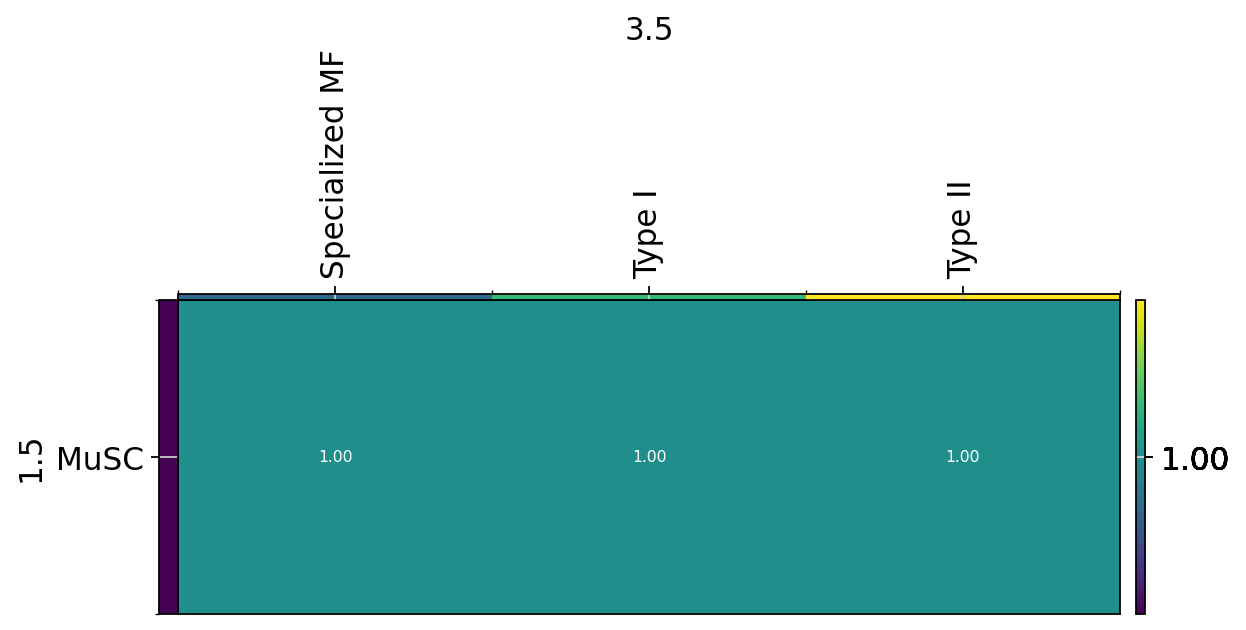

In [20]:
#aggregating the transport matrix by bins of interest
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

W0316 04:22:10.362422  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.388407  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.449896  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.496804  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.557524  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.599490  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.637675  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:22:10.658943  149494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

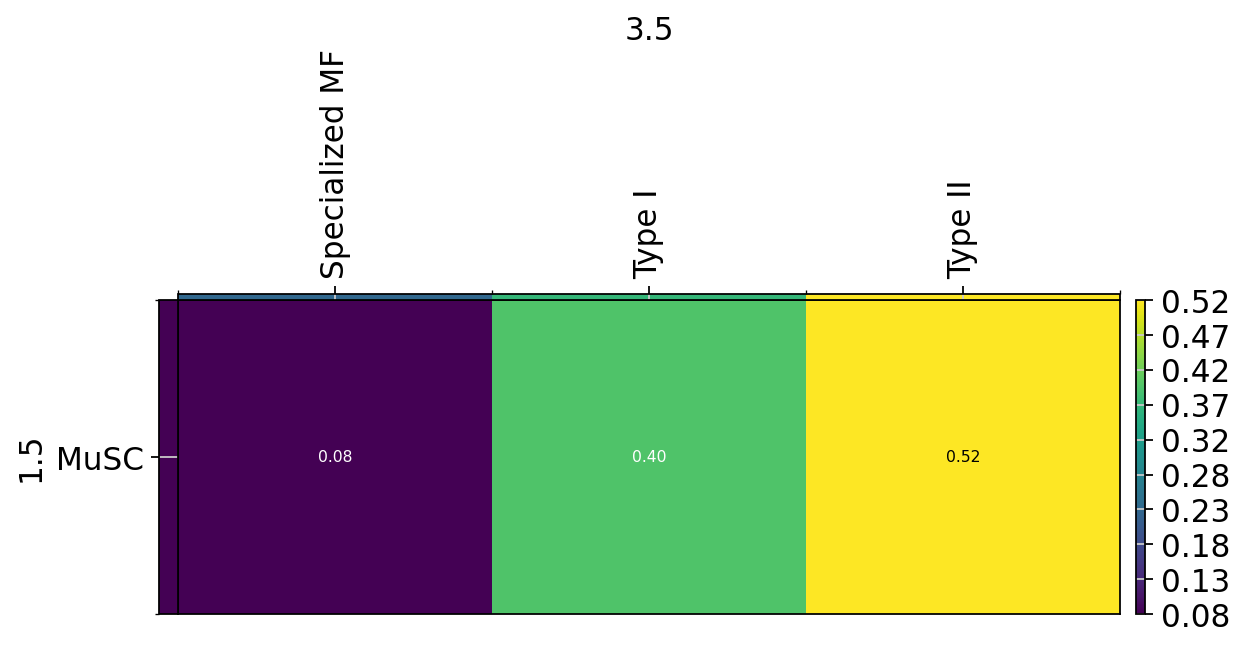

In [21]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

In [22]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

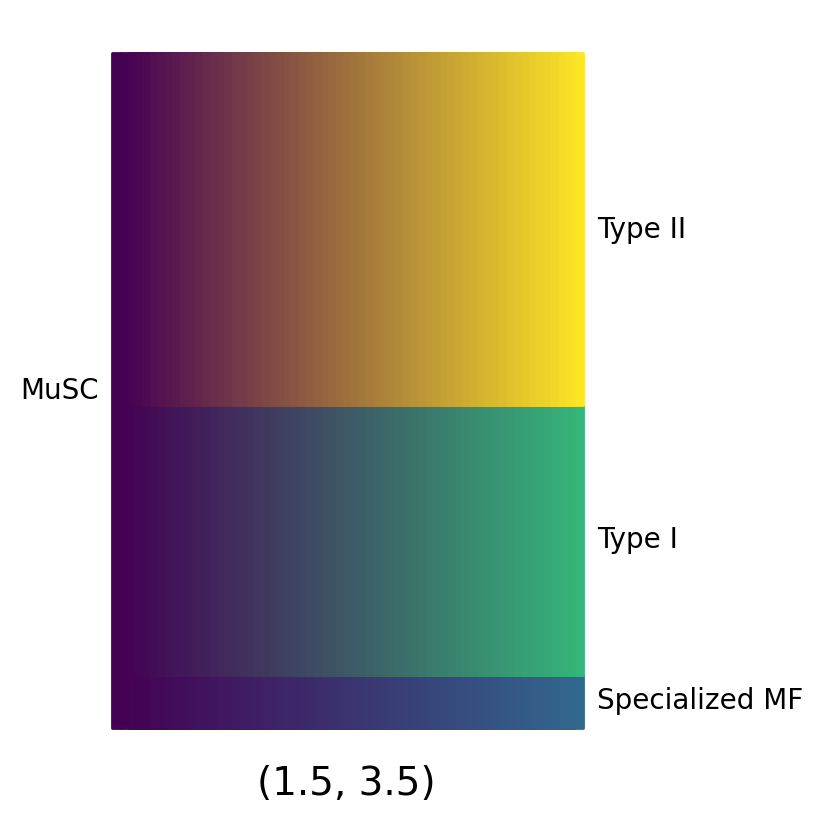

In [23]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [24]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

0.050728977 0.0 7.982279


In [25]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

normalizing counts per cell
    finished (0:00:01)


In [27]:
tp0.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_young,Type II_MuSC_pull
CELL214_N1_1_1_1_2_1_10_1,P26_1,1867.000000,612,P26,1.071237,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,1.5,0.000240
CELL893_N1_1_1_1_2_1_10_1,P26_1,1161.000000,592,P26,3.014643,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,1.5,0.000997
CELL847_N1_1_1_1_2_1_10_1,P26_1,1189.000000,655,P26,1.850294,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,1.5,0.000997
CELL803_N1_1_1_1_2_1_10_1,P26_1,1265.000000,670,P26,0.632411,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,1.5,0.001009
CELL1445_N1_2_1_1_2_1_10_1,P26_2,1909.000000,619,P26,0.366684,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,1.5,0.000992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL2848_N1_2_1_11_1,YM2_2,3378.779154,1326,YM2,0.156017,34.0,snRNA,Female,China,young_pop,Type II,34_Female,3.5,0.000958
CELL1318_N1_1_1_11_1,YM2_1,4901.285016,1650,YM2,0.008360,34.0,snRNA,Female,China,young_pop,Type I,34_Female,3.5,0.000000
CELL699_N1_2_1_11_1,YM2_2,4769.162345,1661,YM2,0.546587,34.0,snRNA,Female,China,young_pop,Type II,34_Female,3.5,0.000958
CELL949_N1_2_1_11_1,YM2_2,4380.935736,1608,YM2,0.057779,34.0,snRNA,Female,China,young_pop,Type II,34_Female,3.5,0.000958


In [29]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type I',
    young_cell_cluster='MuSC',
    cell_cluster_col='Annotation',
    timepoint_col='intervals_young',
    t_young=1.5,
    t_old=3.5,
)

[pull] key='Type I_MuSC_pull' | weight sum = 2.0000
[subset] 1902 cells with Annotation=MuSC at t=1.5
count    1.902000e+03
mean     5.257619e-04
std      3.939864e-04
min      2.926613e-21
25%      6.826965e-05
50%      6.264829e-04
75%      9.120258e-04
max      1.069859e-03
Name: Type I_MuSC_pull, dtype: float64

[result] 22 significant drivers (qval<0.05, |corr|>0.1)


,Type I_MuSC_corr,Type I_MuSC_pval,Type I_MuSC_qval,Type I_MuSC_ci_low,Type I_MuSC_ci_high,significant
ESRRG,0.279730,0.000000,0.000000,0.250551,0.308402,True
PRRX1,0.240014,0.000000,0.000000,0.210219,0.269364,True
CYB5R1,0.183280,0.000000,0.000000,0.152780,0.213431,True
ZSCAN30,0.169948,0.000000,0.000000,0.139313,0.200259,True
MBNL2,0.163011,0.000000,0.000000,0.132309,0.193400,True
KLF12,0.162609,0.000000,0.000000,0.131904,0.193003,True
GLIS3,0.159081,0.000000,0.000000,0.128343,0.189513,True
HADHB,0.152233,0.000000,0.000000,0.121435,0.182738,True
SPATS2,0.131190,0.000000,0.000000,0.100224,0.161902,True
THRB,0.121093,0.000000,0.000000,0.090057,0.151894,True


,Type I_MuSC_corr,Type I_MuSC_pval,Type I_MuSC_qval,Type I_MuSC_ci_low,Type I_MuSC_ci_high,significant
GPD1,-0.224554,0.000000,0.000000,-0.254141,-0.194546,True
NCOA3,-0.206069,0.000000,0.000000,-0.235922,-0.175828,True
TFEB,-0.150969,0.000000,0.000000,-0.181488,-0.120160,True
SETBP1,-0.126429,0.000000,0.000000,-0.157184,-0.095429,True
FOXO1,-0.120735,0.000000,0.000000,-0.151539,-0.089696,True
GBX1,-0.120230,0.000000,0.000000,-0.151038,-0.089188,True
PHF20,-0.104408,0.000000,0.000000,-0.135343,-0.073270,True
RORA,-0.098422,0.000000,0.000000,-0.129400,-0.067251,False
MSRB3,-0.098401,0.000000,0.000000,-0.129379,-0.067230,False
PKM,-0.093910,0.000000,0.000000,-0.124920,-0.062717,False
